In [198]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

from sklearn.utils import resample

mahinay = pd.read_csv("ecommerce_customer_features.csv")

mahinay.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0


In [199]:
mahinay.duplicated().sum()

np.int64(0)

In [200]:
print("Shape:", mahinay.shape)
print(mahinay.dtypes)

mahinay.describe()
mahinay.isnull().sum()

Shape: (6000, 15)
Customer_ID                     object
account_age_months               int64
avg_order_value                float64
total_orders                     int64
days_since_last_purchase         int64
discount_usage_rate            float64
return_rate                    float64
customer_support_tickets         int64
loyalty_member                  object
browsing_frequency_per_week    float64
cart_abandonment_rate          float64
product_review_score_avg       float64
engagement_score               float64
satisfaction_score             float64
price_sensitivity_index        float64
dtype: object


,0
Customer_ID,0
account_age_months,0
avg_order_value,0
total_orders,0
days_since_last_purchase,0
discount_usage_rate,0
return_rate,0
customer_support_tickets,0
loyalty_member,0
browsing_frequency_per_week,0


In [201]:
display(mahinay.dtypes)

,0
Customer_ID,object
account_age_months,int64
avg_order_value,float64
total_orders,int64
days_since_last_purchase,int64
discount_usage_rate,float64
return_rate,float64
customer_support_tickets,int64
loyalty_member,object
browsing_frequency_per_week,float64


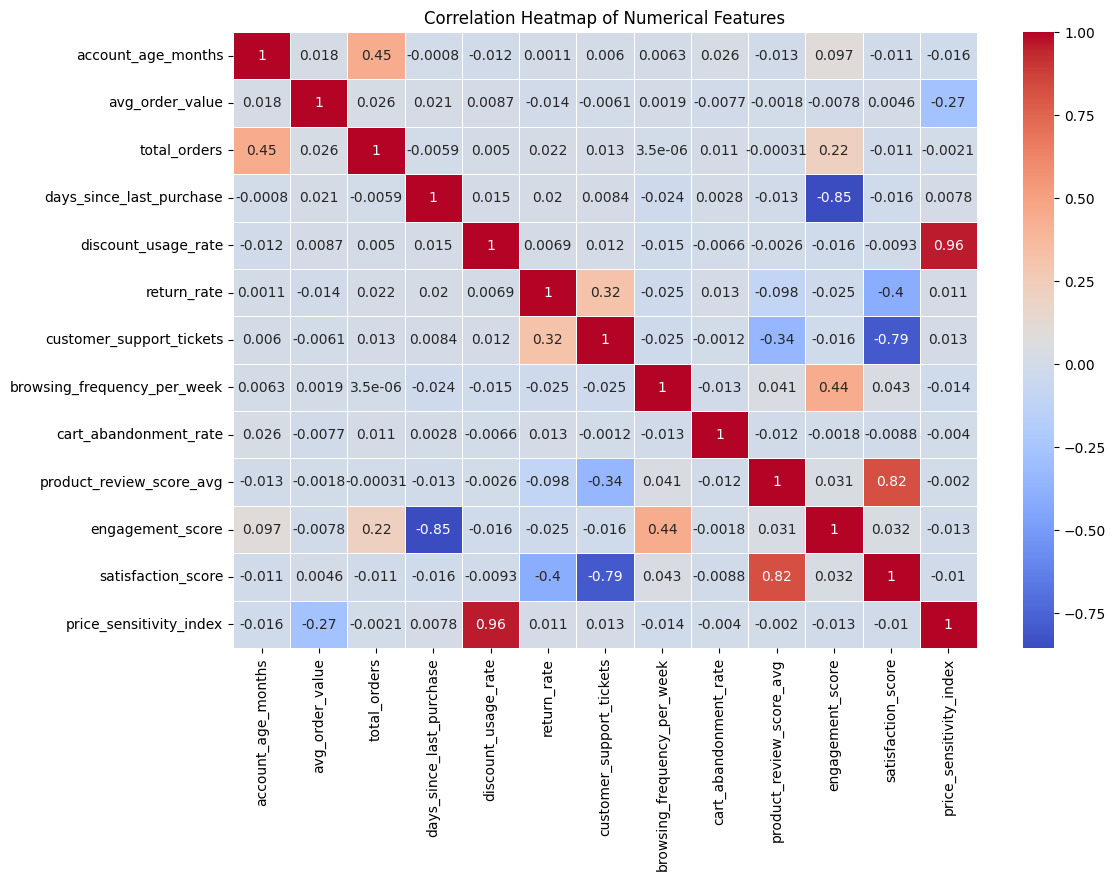

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
correlation_matrix = mahinay.corr(numeric_only=True)

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [203]:
mahinay_clean = mahinay.drop(columns=['Customer_ID'])

display(mahinay_clean['loyalty_member'].value_counts(normalize=True))

print("Cleaned dataset shape:", mahinay_clean.shape)

,proportion
loyalty_member,
No,0.819167
Yes,0.180833


Cleaned dataset shape: (6000, 14)


In [204]:
numerical_cols = mahinay.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = mahinay.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

num_imputer = SimpleImputer(strategy='median')

cat_imputer = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore')


Numerical Columns: Index(['account_age_months', 'avg_order_value', 'total_orders',
       'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
       'customer_support_tickets', 'browsing_frequency_per_week',
       'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score',
       'satisfaction_score', 'price_sensitivity_index'],
      dtype='object')
Categorical Columns: Index(['Customer_ID', 'loyalty_member'], dtype='object')


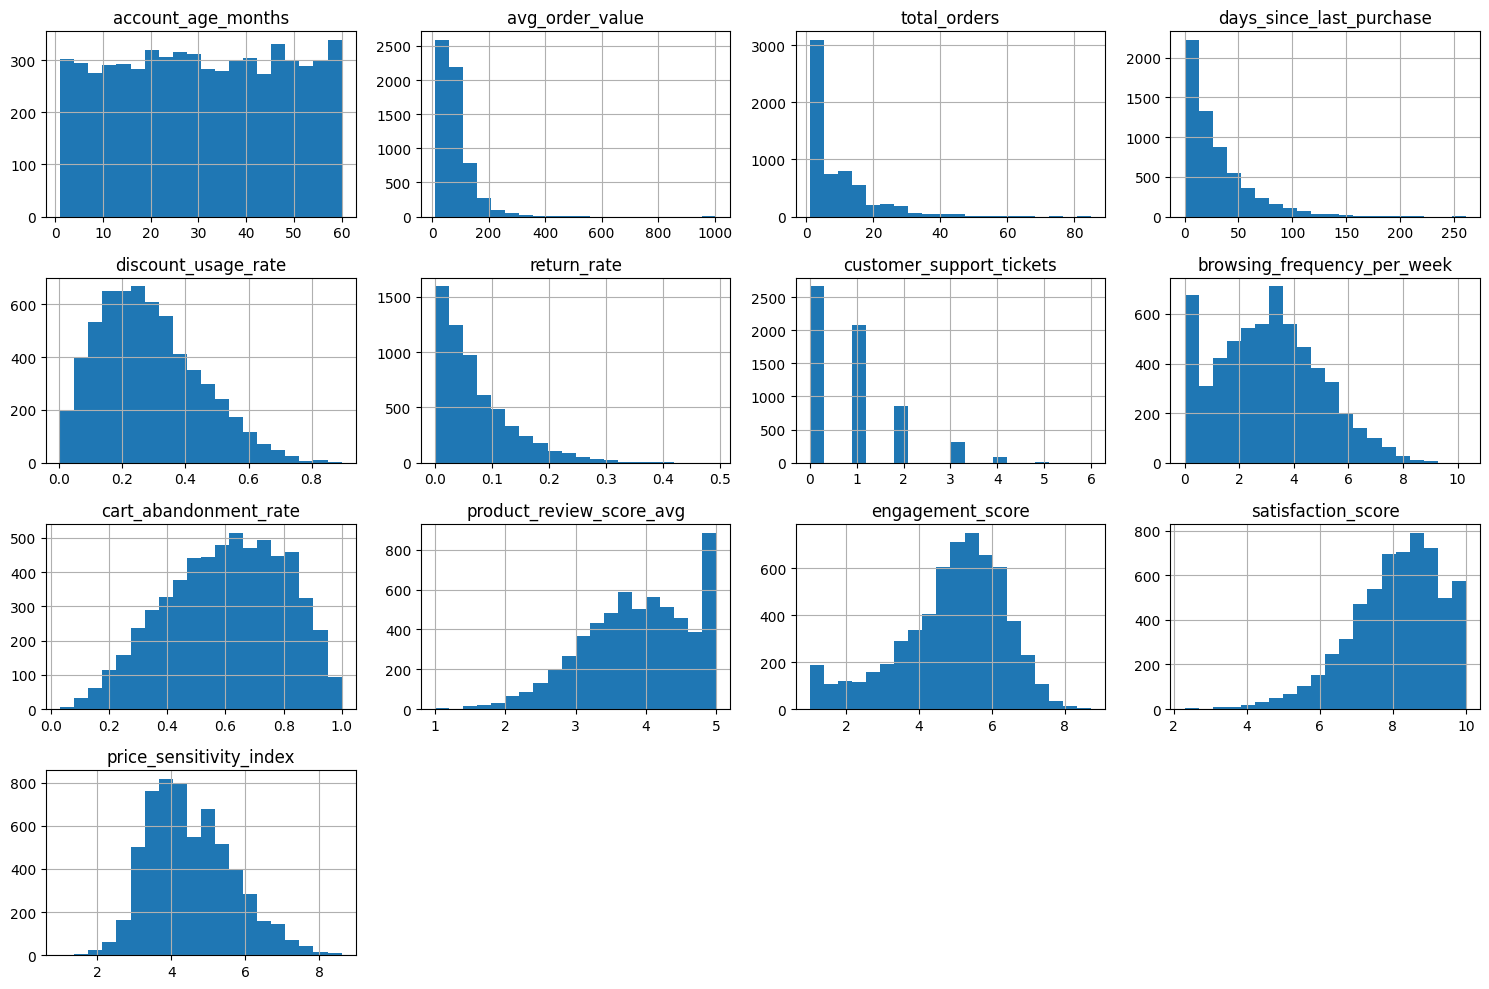

In [205]:
mahinay.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

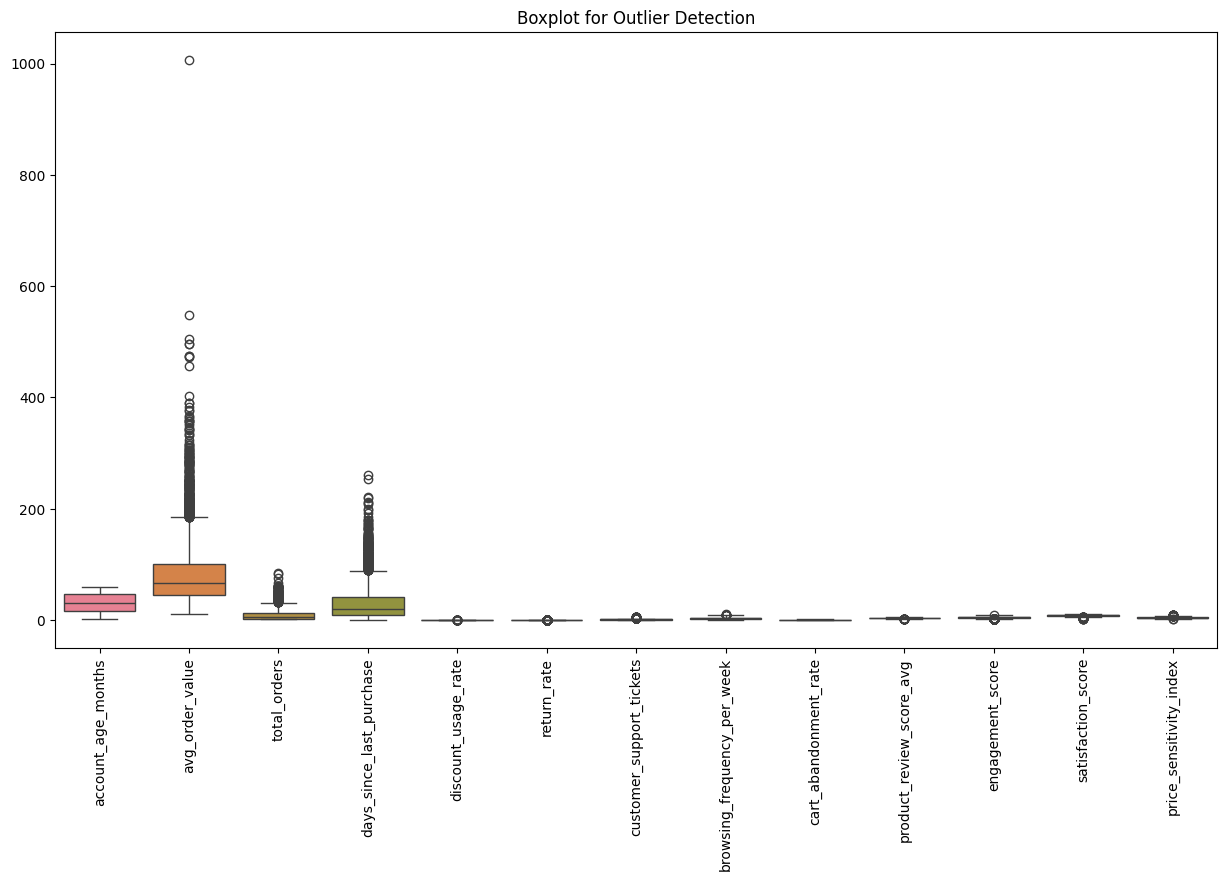

In [206]:
plt.figure(figsize=(15,8))
sns.boxplot(data=mahinay[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

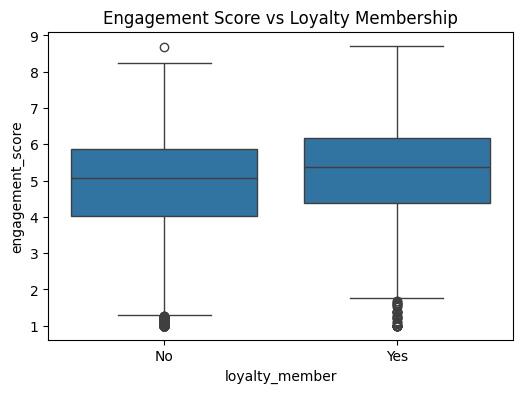

In [207]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loyalty_member', y='engagement_score', data=mahinay)
plt.title("Engagement Score vs Loyalty Membership")
plt.show()

In [208]:
scaler = StandardScaler()

In [209]:
from sklearn.compose import ColumnTransformer

mahinay_clean['loyalty_member'] = mahinay_clean['loyalty_member'].astype(str).str.lower().map({
    'no': 0,
    'yes': 1
})

target = 'loyalty_member'
X = mahinay_clean.drop(columns=[target])
y = mahinay_clean[target]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ])

print("Preprocessor created successfully.")
print("Numerical columns to process:", list(num_cols))
print("Categorical columns to process:", list(cat_cols))
display(y.value_counts())

Preprocessor created successfully.
Numerical columns to process: ['account_age_months', 'avg_order_value', 'total_orders', 'days_since_last_purchase', 'discount_usage_rate', 'return_rate', 'customer_support_tickets', 'browsing_frequency_per_week', 'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score', 'satisfaction_score', 'price_sensitivity_index']
Categorical columns to process: []


,count
loyalty_member,
0,4915
1,1085


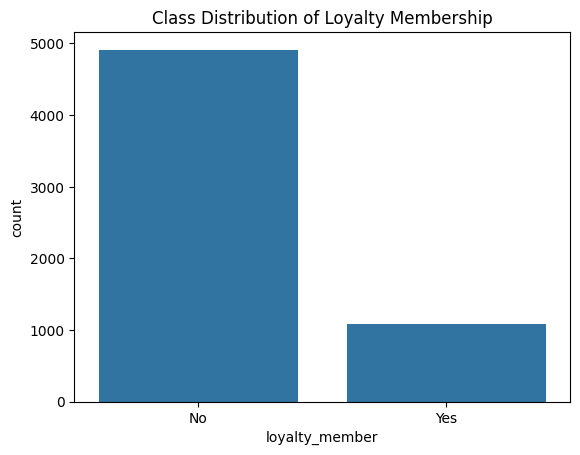

loyalty_member
No     4915
Yes    1085
Name: count, dtype: int64


In [210]:
sns.countplot(x='loyalty_member', data=mahinay)
plt.title("Class Distribution of Loyalty Membership")
plt.show()

print(mahinay['loyalty_member'].value_counts())

In [211]:
def remove_outliers_iqr(data, columns):
    mahinay_clean = data.copy()
    for col in columns:
        Q1 = mahinay_clean[col].quantile(0.25)
        Q3 = mahinay_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mahinay_clean = mahinay_clean[(mahinay_clean[col] >= lower) & (mahinay_clean[col] <= upper)]

    return mahinay_clean

In [212]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nValue counts for y_train (stratified):")
print(y_train.value_counts(normalize=True))

X_train shape: (4800, 13)
X_test shape: (1200, 13)
y_train shape: (4800,)
y_test shape: (1200,)

Value counts for y_train (stratified):
loyalty_member
0    0.819167
1    0.180833
Name: proportion, dtype: float64


## Human-Selected Model Implementation



In [213]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

print("Logistic Regression baseline model trained successfully.")
print(f"First 5 predictions: {y_pred_lr[:5]}")


Logistic Regression baseline model trained successfully.
First 5 predictions: [0 0 0 0 0]


In [214]:
print("=== Logistic Regression Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 0.6975
Precision: 0.3128205128205128
Recall: 0.5622119815668203
F1 Score: 0.40197693574958815
ROC AUC: 0.6748409599129909

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.73      0.80       983
           1       0.31      0.56      0.40       217

    accuracy                           0.70      1200
   macro avg       0.60      0.64      0.60      1200
weighted avg       0.78      0.70      0.73      1200



In [215]:
import pandas as pd

metrics_log = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr)
    ]
})

display(metrics_log)

,Metric,Value
0,Accuracy,0.697500
1,Precision,0.312821
2,Recall,0.562212
3,F1 Score,0.401977
4,ROC AUC,0.674841


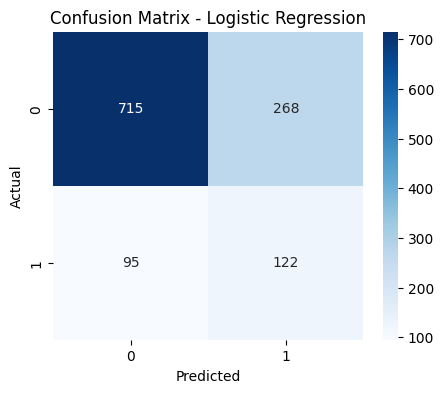

In [216]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## AI-Recommended Model Implementation



In [217]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

print("Random Forest model trained successfully.")
print(f"First 5 predictions: {y_pred_rf[:5]}")

Random Forest model trained successfully.
First 5 predictions: [0 0 0 0 0]


In [218]:
print("=== Random Forest Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.8183333333333334
Precision: 0.47619047619047616
Recall: 0.04608294930875576
F1 Score: 0.08403361344537816
ROC AUC: 0.642721191124696

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.99      0.90       983
           1       0.48      0.05      0.08       217

    accuracy                           0.82      1200
   macro avg       0.65      0.52      0.49      1200
weighted avg       0.76      0.82      0.75      1200



In [219]:
import pandas as pd

metrics_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(metrics_rf)

,Metric,Value
0,Accuracy,0.818333
1,Precision,0.476190
2,Recall,0.046083
3,F1 Score,0.084034
4,ROC AUC,0.642721


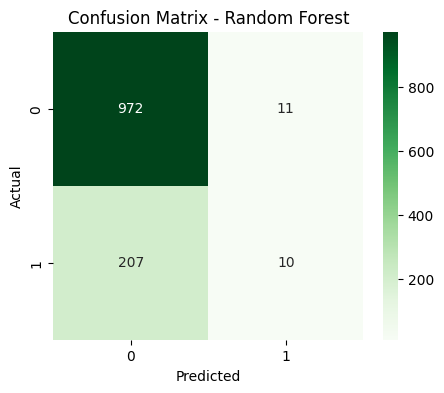

In [220]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

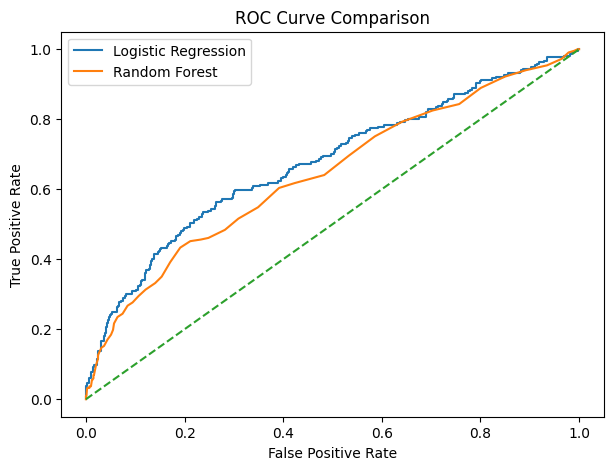

In [221]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [222]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.697500,0.312821,0.562212,0.401977,0.674841
1,Random Forest,0.818333,0.476190,0.046083,0.084034,0.642721


# **Hyperparameter Tuning**

### Subtask:
Refine the best-performing model using GridSearchCV, optimizing for the F1-score to balance precision and recall.


In [223]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_pipeline_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=5000, solver='liblinear', random_state=42))
])

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=lr_pipeline_tune,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-score: {grid_search.best_score_:.4f}")

lr_pipeline_tune = grid_search.best_estimator_

lr_pipeline_tune.fit(X_train, y_train)

y_pred_log_tune = lr_pipeline_tune.predict(X_test)
y_prob_log_tune = lr_pipeline_tune.predict_proba(X_test)[:,1]

print("Logistic Regression pipeline updated and re-fitted with best parameters.")

Best Parameters: {'classifier__C': 1, 'classifier__penalty': 'l1'}
Best Cross-Validation F1-score: 0.1437
Logistic Regression pipeline updated and re-fitted with best parameters.


In [224]:
print("=== Logistic Regression Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred_log_tune))
print("Precision:", precision_score(y_test, y_pred_log_tune))
print("Recall:", recall_score(y_test, y_pred_log_tune))
print("F1 Score:", f1_score(y_test, y_pred_log_tune))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log_tune))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log_tune))

=== Logistic Regression Results ===
Accuracy: 0.8233333333333334
Precision: 0.6
Recall: 0.06912442396313365
F1 Score: 0.12396694214876033
ROC AUC: 0.6711327592107298

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.99      0.90       983
           1       0.60      0.07      0.12       217

    accuracy                           0.82      1200
   macro avg       0.71      0.53      0.51      1200
weighted avg       0.79      0.82      0.76      1200



In [225]:
metrics_log = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_log_tune ),
        precision_score(y_test, y_pred_log_tune ),
        recall_score(y_test, y_pred_log_tune ),
        f1_score(y_test, y_pred_log_tune ),
        roc_auc_score(y_test, y_prob_log_tune )
    ]
})

display(metrics_log)

,Metric,Value
0,Accuracy,0.823333
1,Precision,0.600000
2,Recall,0.069124
3,F1 Score,0.123967
4,ROC AUC,0.671133


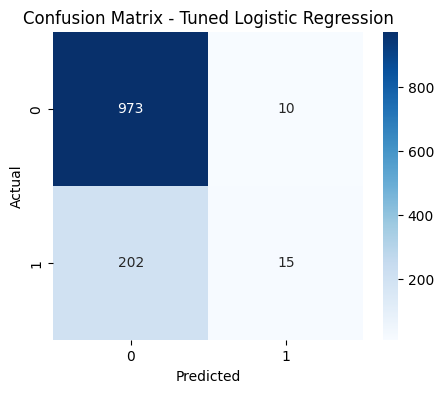

In [226]:
cm_log_tune = confusion_matrix(y_test, y_pred_log_tune)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_tune, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_441/2976094679.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='vlag')


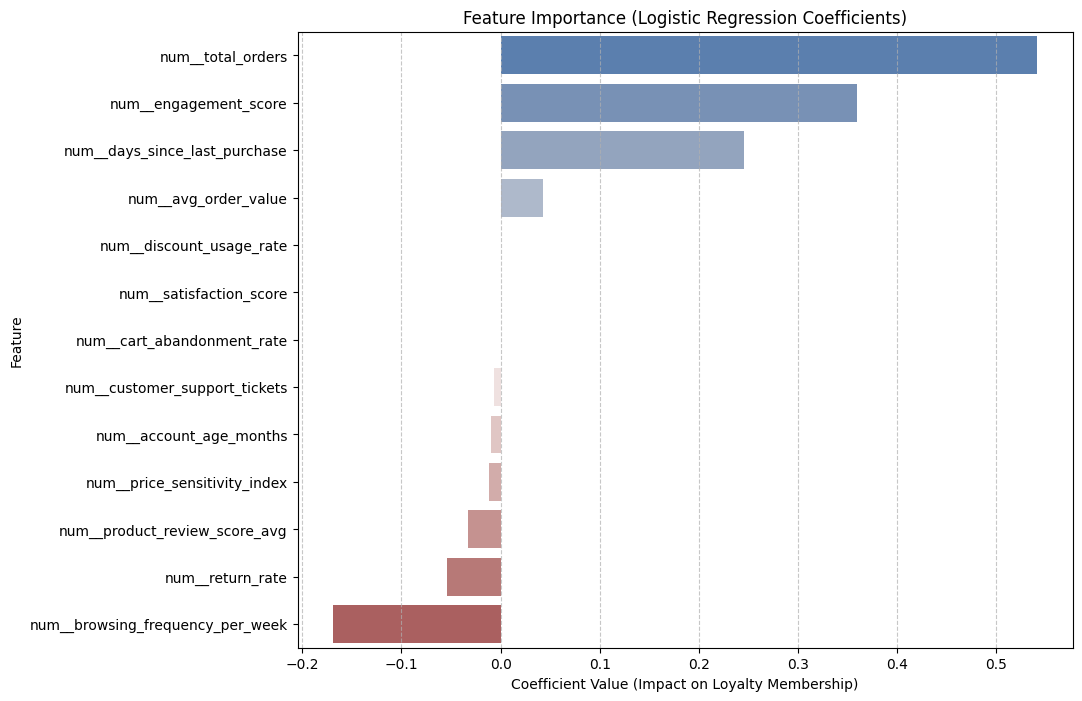

Top Features driving Loyalty Membership:


,Feature,Coefficient
2,num__total_orders,0.541277
10,num__engagement_score,0.359763
3,num__days_since_last_purchase,0.245186
1,num__avg_order_value,0.042337
4,num__discount_usage_rate,0.000000



Top Features decreasing Loyalty Membership likelihood:


,Feature,Coefficient
0,num__account_age_months,-0.010078
12,num__price_sensitivity_index,-0.011313
9,num__product_review_score_avg,-0.032548
5,num__return_rate,-0.054499
7,num__browsing_frequency_per_week,-0.169251


In [227]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = preprocessor.get_feature_names_out()

coefficients = lr_pipeline_tune.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['abs_importance'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='vlag')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value (Impact on Loyalty Membership)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top Features driving Loyalty Membership:")
display(feature_importance[['Feature', 'Coefficient']].head())
print("\nTop Features decreasing Loyalty Membership likelihood:")
display(feature_importance[['Feature', 'Coefficient']].tail())

In [228]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid with correct pipeline prefixes
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1],
    'classifier__max_features': ['sqrt']
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("Tuning Random Forest... this may take a moment.")
rf_grid_search.fit(X_train, y_train)

print(f"Best RF Parameters: {rf_grid_search.best_params_}")
print(f"Best RF Cross-Validation F1-score: {rf_grid_search.best_score_:.4f}")

rf_pipeline_tuned = rf_grid_search.best_estimator_
y_pred_rf_tuned = rf_pipeline_tuned.predict(X_test)
y_prob_rf_tuned = rf_pipeline_tuned.predict_proba(X_test)[:, 1]

print("\n--- Tuned Random Forest Classification Report ---")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf_tuned))

Tuning Random Forest... this may take a moment.
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best RF Parameters: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}
Best RF Cross-Validation F1-score: 0.3150

--- Tuned Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       983
           1       0.37      0.35      0.36       217

    accuracy                           0.78      1200
   macro avg       0.62      0.61      0.61      1200
weighted avg       0.77      0.78      0.77      1200



In [229]:
metrics_log = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_rf_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
})

display(metrics_log)

,Metric,Value
0,Accuracy,0.776667
1,Precision,0.374384
2,Recall,0.350230
3,F1 Score,0.361905
4,ROC AUC,0.640000


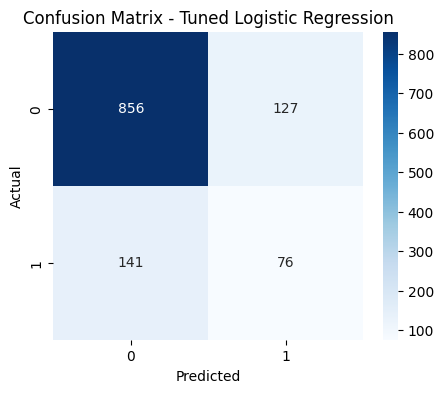

In [230]:
cm_log_tune = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_tune, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_441/710336281.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')


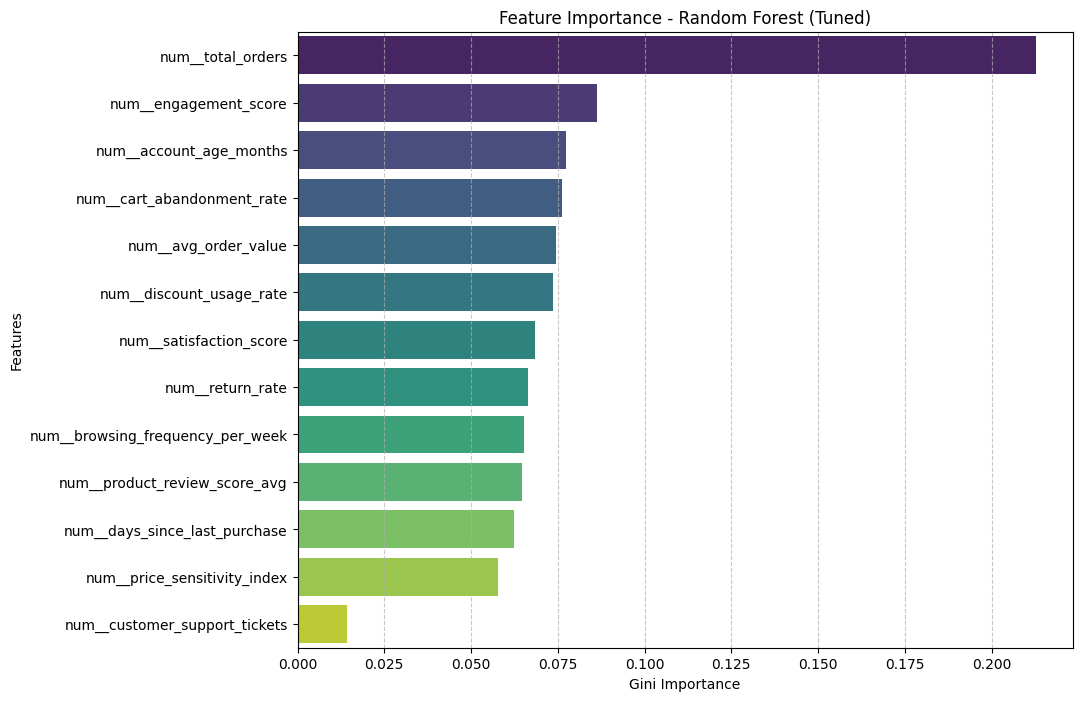

Top 5 Most Important Features (Random Forest):


,Feature,Importance
2,num__total_orders,0.212665
10,num__engagement_score,0.086417
0,num__account_age_months,0.077250
8,num__cart_abandonment_rate,0.076085
1,num__avg_order_value,0.074585


In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_pipeline_tuned.named_steps['classifier'].feature_importances_
feature_names = preprocessor.get_feature_names_out()

rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')
plt.title("Feature Importance - Random Forest (Tuned)")
plt.xlabel("Gini Importance")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 5 Most Important Features (Random Forest):")
display(rf_feature_importance.head(5))

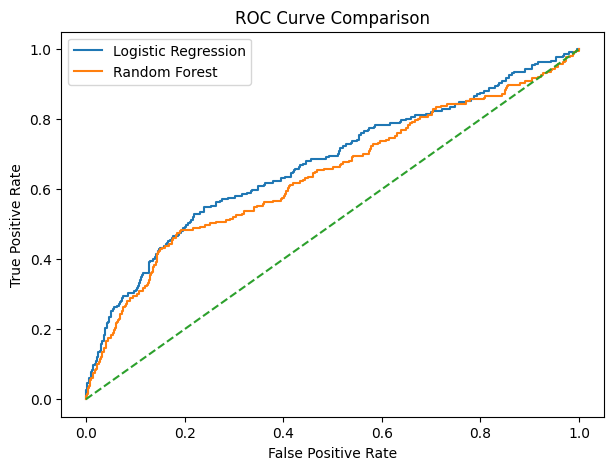

In [232]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log_tune)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [233]:
import joblib

model_bundle = {
    'logistic_regression_model': lr_pipeline_tune,
    'random_forest_model': rf_pipeline_tuned,
    'preprocessor': preprocessor,
    'feature_columns': list(X.columns)
}

joblib.dump(model_bundle, 'customer_loyalty_model_bundle_v3.pkl')

print("Model bundle saved as 'customer_loyalty_model_bundle_v3.pkl'")
print("Contents: Tuned Logistic Regression, Tuned Random Forest, Preprocessor, and Feature Columns.")

Model bundle saved as 'customer_loyalty_model_bundle_v3.pkl'
Contents: Tuned Logistic Regression, Tuned Random Forest, Preprocessor, and Feature Columns.
